# How to Evaluate Machine Learning & Deep Learning Models

---


**What we'll cover:**
1. Setup & Imports
2. Dataset Preparation
3. Training a Machine Learning Model (Classification)
4. Classification Metrics — Accuracy, Precision, Recall, F1
5. ROC Curve & AUC
6. Cross-Validation
7. Regression Metrics — MAE, MSE, R²
8. Deep Learning Model Evaluation
9. Overfitting vs Underfitting — How to Spot It
10. Putting It All Together — Best Practices

---
> Note: **Tip for students:** Read every markdown cell carefully before running the code. The explanation is just as important as the code itself!


---
## Section 1: Setup & Imports

Before we start, we need to import the tools (libraries) we'll use throughout this notebook.

- **NumPy / Pandas** — for handling data
- **Matplotlib / Seaborn** — for drawing charts
- **Scikit-learn** — for machine learning models and evaluation metrics
- **TensorFlow / Keras** — for building and evaluating deep learning models


In [ ]:
# ── Core libraries ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn ─────────────────────────────────────────────────
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Metrics for classification
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score
)

# Metrics for regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Deep Learning ─────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ── Styling ───────────────────────────────────────────────────────
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('[OK] All libraries imported successfully!')
print(f' TensorFlow version: {tf.__version__}')

[OK] All libraries imported successfully!
 TensorFlow version: 2.19.0


---
## Section 2: Preparing Our Dataset

We'll use the **Breast Cancer Wisconsin Dataset** — a classic dataset for binary classification.

**The Task:** Given measurements of a tumor (like size, texture, etc.), predict whether it is:
- `1` = **Benign** (not cancer)
- `0` = **Malignant** (cancer)

**Why this dataset?**
- It's real-world data
- Easy to understand
- Good for showing why evaluation metrics matter (false negatives here = missed cancer!)


 Dataset Overview
 Total samples : 569
 Total features : 30
 Classes : {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}


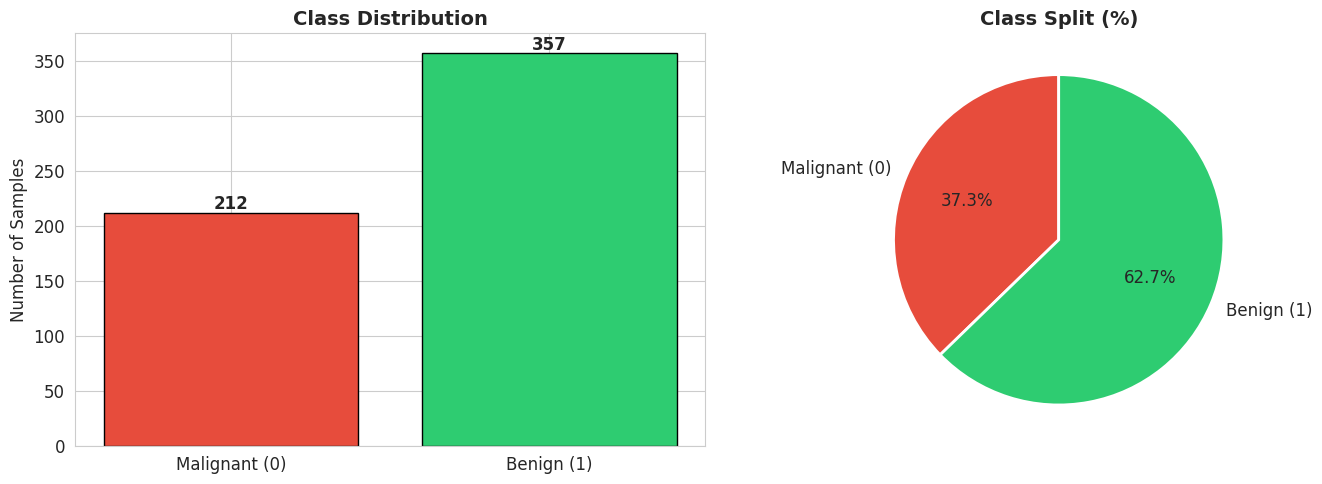


[OK] Split done!
 Training samples : 455
 Testing samples : 114


In [ ]:
# ── Load the dataset ────────────────────────────────────────────
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target') # 0 = malignant, 1 = benign

print(' Dataset Overview')
print(f' Total samples : {X.shape[0]}')
print(f' Total features : {X.shape[1]}')
print(f' Classes : {dict(zip(data.target_names, np.bincount(y)))}')

# ── Visualize class distribution ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
class_counts = y.value_counts()
axes[0].bar(['Malignant (0)', 'Benign (1)'], [class_counts[0], class_counts[1]],
 color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
for i, v in enumerate([class_counts[0], class_counts[1]]):
 axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie([class_counts[0], class_counts[1]],
 labels=['Malignant (0)', 'Benign (1)'],
 colors=['#e74c3c', '#2ecc71'],
 autopct='%1.1f%%', startangle=90,
 wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Split (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ── Train / Test Split ──────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.2, random_state=42, stratify=y # stratify = keep class balance
)

# ── Feature Scaling ─────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # fit on training data only!
X_test_scaled = scaler.transform(X_test) # just transform (no fitting) on test

print(f'\n[OK] Split done!')
print(f' Training samples : {X_train.shape[0]}')
print(f' Testing samples : {X_test.shape[0]}')


> [WARNING] **Important concept — Why do we split data?**
>
> We **train** on one portion of data, and **test** on a completely separate portion.
> This way we can check: *"Does my model actually learn, or did it just memorize the training data?"*
>
> Think of it like studying for an exam with practice questions, then taking a **different** final exam.


---
## Section 3: Training a Classification Model

We'll train **3 models** so we can compare them:
1. **Logistic Regression** — simple, fast, linear
2. **Random Forest** — ensemble of decision trees, more powerful
3. **Support Vector Machine (SVM)** — finds the best boundary between classes


In [ ]:
# ── Define models ────────────────────────────────────────────────
models = {
 'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
 'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=42),
 'SVM' : SVC(probability=True, random_state=42)
}

# ── Train all models ─────────────────────────────────────────────
trained_models = {}
for name, model in models.items():
 model.fit(X_train_scaled, y_train)
 trained_models[name] = model
 print(f'[OK] {name} trained!')

print('\n All models are trained and ready for evaluation!')


[OK] Logistic Regression trained!
[OK] Random Forest trained!
[OK] SVM trained!

 All models are trained and ready for evaluation!


---
## Section 4: Classification Metrics

### The Big Question: What does "good" mean?

Just saying *"my model is 95% accurate"* is often **not enough**. Let me show you why.

### The Confusion Matrix — Start Here!

The **confusion matrix** is a table that shows 4 types of outcomes:

| | Predicted: Negative | Predicted: Positive |
|---|---|---|
| **Actual: Negative** | [OK] True Negative (TN) | [BAD] False Positive (FP) |
| **Actual: Positive** | [BAD] False Negative (FN) | [OK] True Positive (TP) |

- **TP** = We said cancer, it IS cancer [OK]
- **TN** = We said no cancer, there ISN'T cancer [OK]
- **FP** = We said cancer, but it's NOT cancer [BAD] (False Alarm)
- **FN** = We said no cancer, but it IS cancer [BAD] (Missed Cancer — DANGEROUS!)

### The 4 Key Metrics

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

$$\text{Precision} = \frac{TP}{TP + FP} \quad \leftarrow \text{"Of all I said positive, how many were right?"}$$

$$\text{Recall} = \frac{TP}{TP + FN} \quad \leftarrow \text{"Of all actual positives, how many did I catch?"}$$

$$\text{F1 Score} = 2 \times \frac{Precision \times Recall}{Precision + Recall} \quad \leftarrow \text{Balance of Precision and Recall}$$


 Model Performance Summary
                     Accuracy  Precision  Recall  F1 Score
Model                                                     
Logistic Regression    0.9825     0.9861  0.9861    0.9861
Random Forest          0.9561     0.9589  0.9722    0.9655
SVM                    0.9825     0.9861  0.9861    0.9861


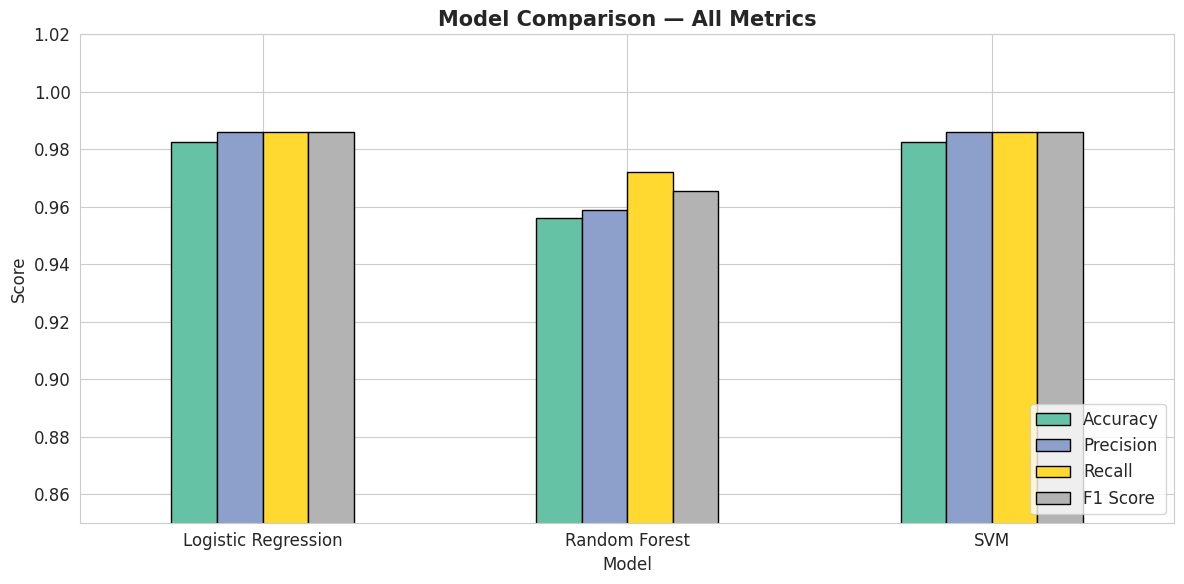

In [ ]:
# ── Evaluate all models and collect metrics ───────────────────────
results = []

for name, model in trained_models.items():
 y_pred = model.predict(X_test_scaled)

 acc = accuracy_score(y_test, y_pred)
 prec = precision_score(y_test, y_pred)
 rec = recall_score(y_test, y_pred)
 f1 = f1_score(y_test, y_pred)

 results.append({
 'Model' : name,
 'Accuracy' : round(acc, 4),
 'Precision' : round(prec, 4),
 'Recall' : round(rec, 4),
 'F1 Score' : round(f1, 4)
 })

# ── Show as a nice table ──────────────────────────────────────────
results_df = pd.DataFrame(results).set_index('Model')
print(' Model Performance Summary')
print('=' * 60)
print(results_df.to_string())

# ── Bar chart comparison ─────────────────────────────────────────
results_df.plot(kind='bar', figsize=(12, 6), colormap='Set2', edgecolor='black')
plt.title('Model Comparison — All Metrics', fontsize=15, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0.85, 1.02)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


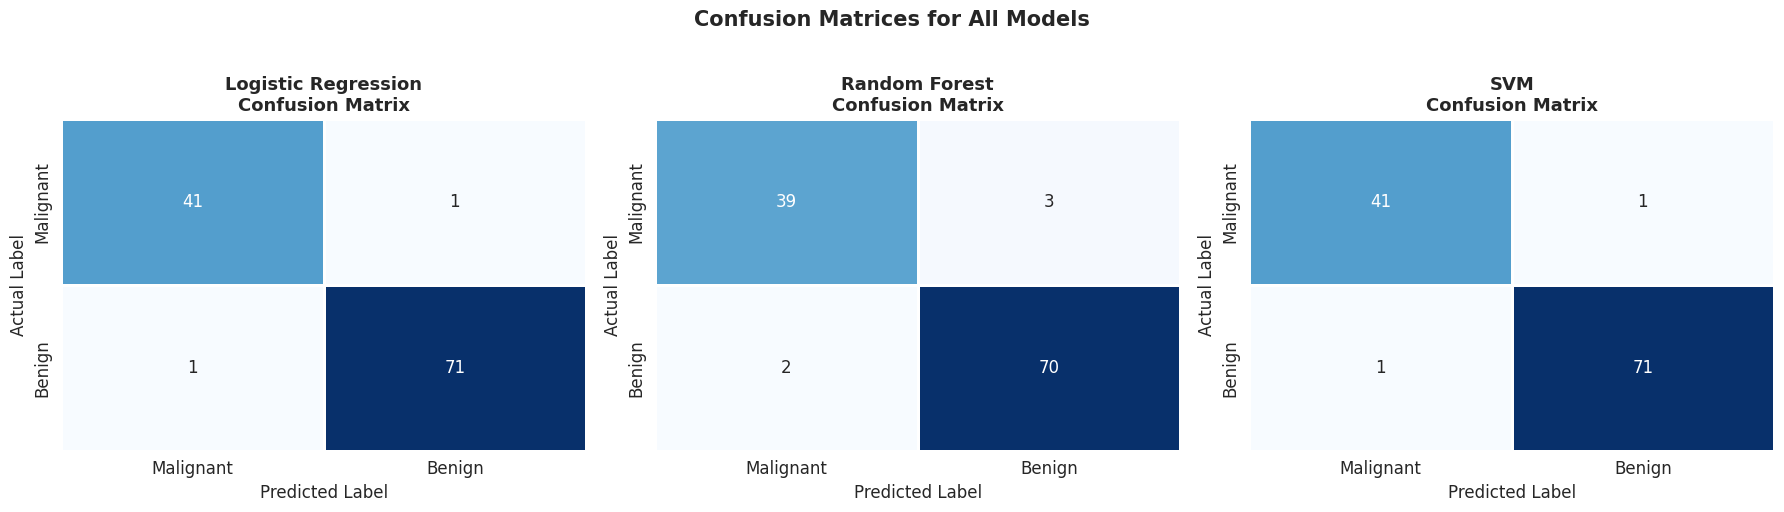


 Full Classification Report — Random Forest
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [ ]:
# ── Confusion Matrices — one for each model ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, trained_models.items()):
 y_pred = model.predict(X_test_scaled)
 cm = confusion_matrix(y_test, y_pred)

 sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
 xticklabels=['Malignant', 'Benign'],
 yticklabels=['Malignant', 'Benign'],
 linewidths=2, linecolor='white', cbar=False)

 ax.set_title(f'{name}\nConfusion Matrix', fontweight='bold', fontsize=13)
 ax.set_ylabel('Actual Label')
 ax.set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrices for All Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Full Classification Report for best model ─────────────────────
print('\n Full Classification Report — Random Forest')
print('=' * 55)
y_pred_rf = trained_models['Random Forest'].predict(X_test_scaled)
print(classification_report(y_test, y_pred_rf,
 target_names=['Malignant', 'Benign']))


---
## Section 5: ROC Curve & AUC Score

### What is an ROC Curve?

ROC = **Receiver Operating Characteristic**

It shows the trade-off between:
- **True Positive Rate (Recall)** — how many real positives did we catch?
- **False Positive Rate** — how many negatives did we wrongly call positive?

### What is AUC?

**AUC = Area Under the ROC Curve**

| AUC Value | Meaning |
|---|---|
| 1.0 | Perfect model |
| 0.9 - 1.0 | Excellent |
| 0.8 - 0.9 | Good |
| 0.7 - 0.8 | Fair |
| 0.5 | Random guessing (useless!) |
| < 0.5 | Worse than random |

> Note: **Key point:** The closer the ROC curve hugs the top-left corner, the better your model is!


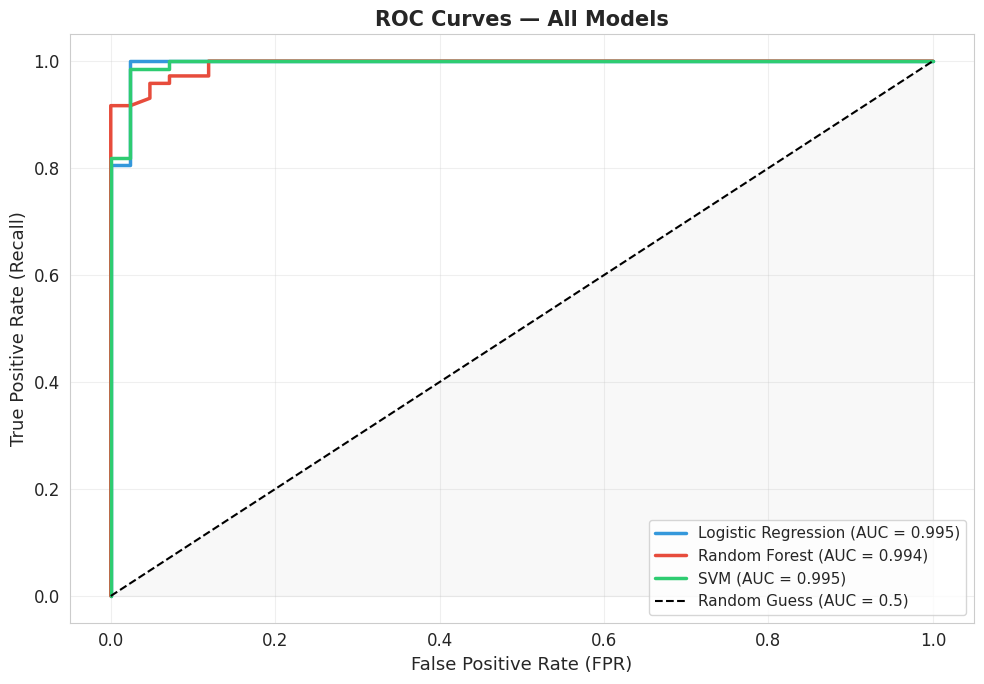

In [ ]:
# ── Plot ROC Curves for all models ───────────────────────────────
plt.figure(figsize=(10, 7))

colors = ['#3498db', '#e74c3c', '#2ecc71']

for (name, model), color in zip(trained_models.items(), colors):
 # Get probability scores (not just 0/1 predictions)
 y_prob = model.predict_proba(X_test_scaled)[:, 1]

 fpr, tpr, thresholds = roc_curve(y_test, y_prob)
 auc_score = roc_auc_score(y_test, y_prob)

 plt.plot(fpr, tpr, color=color, linewidth=2.5,
 label=f'{name} (AUC = {auc_score:.3f})')

# The diagonal = random classifier baseline
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Guess (AUC = 0.5)')

plt.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')

plt.xlabel('False Positive Rate (FPR)', fontsize=13)
plt.ylabel('True Positive Rate (Recall)', fontsize=13)
plt.title('ROC Curves — All Models', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## Section 6: Cross-Validation

### Why Cross-Validation?

A single train/test split can be **lucky or unlucky**. Maybe you happened to get easy test samples, or hard ones.

**Cross-Validation** solves this by:
1. Splitting data into **K equal parts (folds)**
2. Training on K-1 folds, testing on the 1 remaining fold
3. Repeating K times (each fold gets a turn as the test set)
4. Averaging the scores → much more **reliable estimate**!

```
 5-Fold Cross-Validation (K=5):

 Fold 1: [TEST] [train] [train] [train] [train]
 Fold 2: [train] [TEST] [train] [train] [train]
 Fold 3: [train] [train] [TEST] [train] [train]
 Fold 4: [train] [train] [train] [TEST] [train]
 Fold 5: [train] [train] [train] [train] [TEST]

 Final score = average of all 5 test scores
```


 5-Fold Cross-Validation Results

Logistic Regression:
 Fold Scores : [np.float64(0.9744), np.float64(0.9912), np.float64(0.9825), np.float64(0.9913), np.float64(0.9735)]
 Mean F1 : 0.9825
 Std Dev : 0.0078 ← lower is more stable

Random Forest:
 Fold Scores : [np.float64(0.9735), np.float64(0.9643), np.float64(0.9464), np.float64(0.9744), np.float64(0.9912)]
 Mean F1 : 0.9699
 Std Dev : 0.0146 ← lower is more stable

SVM:
 Fold Scores : [np.float64(0.9573), np.float64(0.9821), np.float64(0.9643), np.float64(0.9739), np.float64(0.9913)]
 Mean F1 : 0.9738
 Std Dev : 0.0122 ← lower is more stable


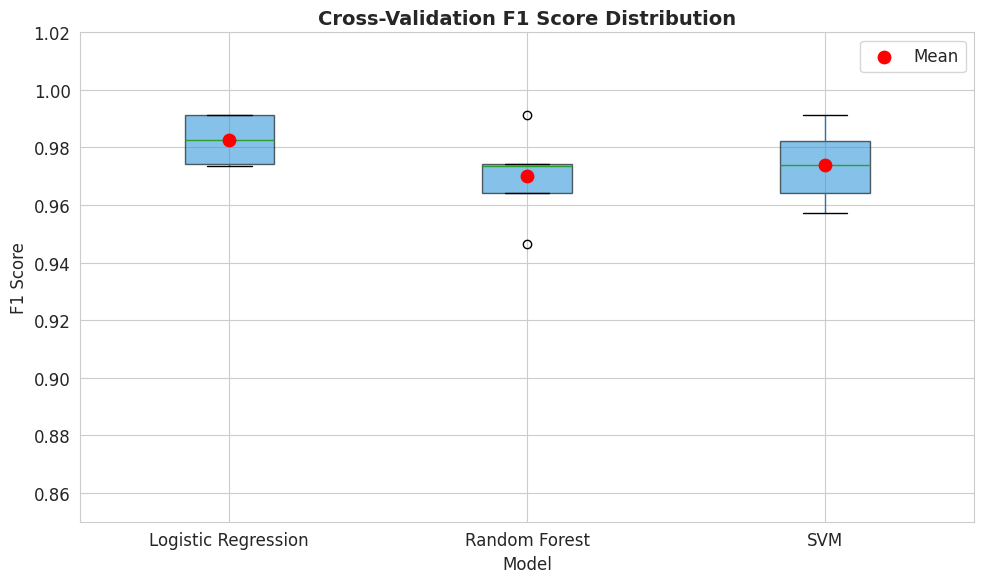


Note: A smaller std dev means the model is more CONSISTENT across different data splits.


In [ ]:
# ── 5-Fold Stratified Cross-Validation ───────────────────────────
# Stratified = each fold keeps same class ratio as original data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(' 5-Fold Cross-Validation Results')
print('=' * 55)

cv_results = {}

for name, model in trained_models.items():
 scores = cross_val_score(model, X_train_scaled, y_train,
 cv=cv, scoring='f1')
 cv_results[name] = scores
 print(f'\n{name}:')
 print(f' Fold Scores : {[round(s, 4) for s in scores]}')
 print(f' Mean F1 : {scores.mean():.4f}')
 print(f' Std Dev : {scores.std():.4f} ← lower is more stable')

# ── Visualize CV distributions ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

cv_df = pd.DataFrame(cv_results)
cv_df.boxplot(ax=ax, patch_artist=True,
 boxprops=dict(facecolor='#3498db', alpha=0.6))

ax.set_title('Cross-Validation F1 Score Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_xlabel('Model')
ax.set_ylim(0.85, 1.02)

# Add mean dots
for i, col in enumerate(cv_df.columns, 1):
 ax.scatter(i, cv_df[col].mean(), color='red', zorder=5, s=80, label='Mean' if i==1 else '')

ax.legend()
plt.tight_layout()
plt.show()

print('\nNote: A smaller std dev means the model is more CONSISTENT across different data splits.')


---
## Section 7: Regression Metrics

So far we've been doing **classification** (predicting a category).
Now let's look at **regression** (predicting a number, e.g. house price).

### The 3 Most Common Regression Metrics

| Metric | Formula | What it means |
|---|---|---|
| **MAE** (Mean Absolute Error) | Average of $|y - \hat{y}|$ | Average error in original units. Easy to understand |
| **MSE** (Mean Squared Error) | Average of $(y - \hat{y})^2$ | Penalizes large errors more heavily |
| **RMSE** (Root MSE) | $\sqrt{MSE}$ | Like MSE but in original units |
| **R² Score** | $1 - \frac{SS_{res}}{SS_{tot}}$ | How much variance did the model explain? (1.0 = perfect, 0 = baseline) |

> Note: **R² = 0.85** means the model explains 85% of the variability in the data.


 Regression Metrics
 MAE (Mean Absolute Error) : 3.3550
 MSE (Mean Squared Error) : 17.3540
 RMSE (Root MSE) : 4.1658
 R² (R-Squared) : 0.8327

 ℹ Model explains 83.3% of the variance in target values.


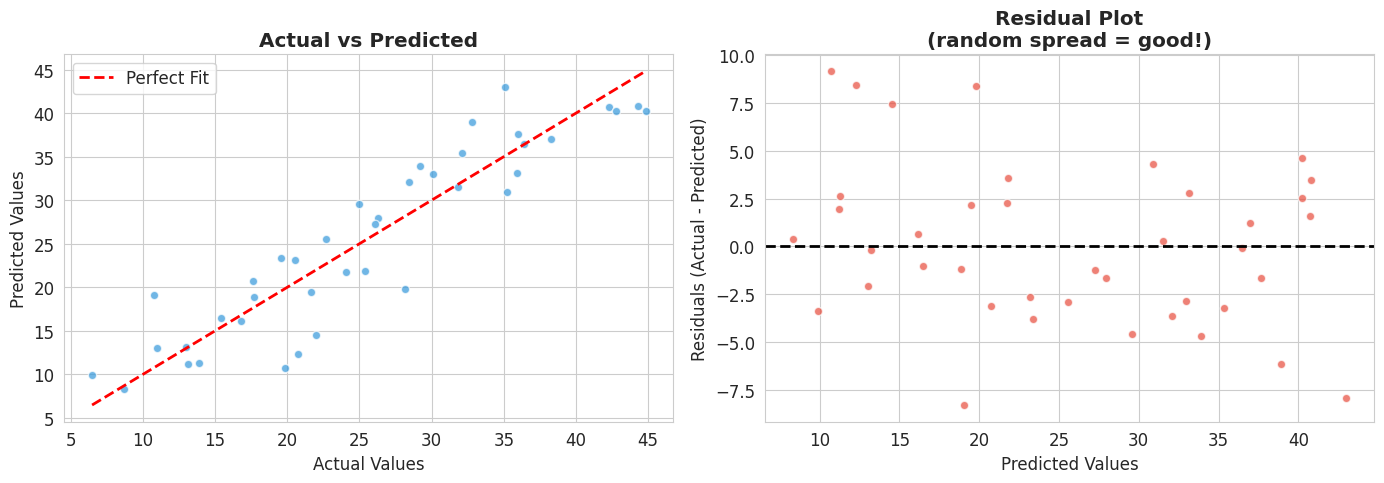

In [ ]:
# ── Create a synthetic regression dataset ────────────────────────
np.random.seed(42)
n = 200
X_reg = np.random.rand(n, 1) * 10 # single feature: 0 to 10
y_reg = 3.5 * X_reg.ravel() + 8 + np.random.randn(n) * 4 # linear + noise

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
 X_reg, y_reg, test_size=0.2, random_state=42
)

# ── Fit a linear regression model ────────────────────────────────
reg_model = LinearRegression()
reg_model.fit(X_reg_train, y_reg_train)
y_reg_pred = reg_model.predict(X_reg_test)

# ── Calculate regression metrics ─────────────────────────────────
mae = mean_absolute_error(y_reg_test, y_reg_pred)
mse = mean_squared_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_reg_test, y_reg_pred)

print(' Regression Metrics')
print('=' * 40)
print(f' MAE (Mean Absolute Error) : {mae:.4f}')
print(f' MSE (Mean Squared Error) : {mse:.4f}')
print(f' RMSE (Root MSE) : {rmse:.4f}')
print(f' R² (R-Squared) : {r2:.4f}')
print(f'\n ℹ Model explains {r2*100:.1f}% of the variance in target values.')

# ── Plot: Actual vs Predicted ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter of predictions vs actual
axes[0].scatter(y_reg_test, y_reg_pred, color='#3498db', alpha=0.7, edgecolors='white')
min_val = min(y_reg_test.min(), y_reg_pred.min())
max_val = max(y_reg_test.max(), y_reg_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Fit')
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')
axes[0].set_title('Actual vs Predicted', fontweight='bold')
axes[0].legend()

# Right: residual plot
residuals = y_reg_test - y_reg_pred
axes[1].scatter(y_reg_pred, residuals, color='#e74c3c', alpha=0.7, edgecolors='white')
axes[1].axhline(0, color='black', linewidth=2, linestyle='--')
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].set_title('Residual Plot\n(random spread = good!)', fontweight='bold')

plt.tight_layout()
plt.show()


---
## Section 8: Deep Learning Model Evaluation

Deep Learning (Neural Networks) have their own evaluation workflow.

### Key concepts specific to Deep Learning:

| Concept | Meaning |
|---|---|
| **Epoch** | One full pass through the training data |
| **Loss** | How wrong the model is — we want this to go DOWN |
| **Validation Loss** | Loss on data the model has never seen — should track training loss |
| **Training Curve** | Plotting loss/accuracy over epochs to see learning progress |

We'll build a simple neural network on the same breast cancer dataset.


In [ ]:
# ── Build the Neural Network ──────────────────────────────────────
tf.random.set_seed(42)

dl_model = keras.Sequential([
 layers.Input(shape=(X_train_scaled.shape[1],)), # Input: 30 features

 layers.Dense(64, activation='relu'), # Hidden layer 1: 64 neurons
 layers.BatchNormalization(), # Helps training stability
 layers.Dropout(0.3), # Prevent overfitting

 layers.Dense(32, activation='relu'), # Hidden layer 2: 32 neurons
 layers.Dropout(0.2),

 layers.Dense(1, activation='sigmoid') # Output: probability (0 to 1)
])

dl_model.compile(
 optimizer='adam',
 loss='binary_crossentropy', # for binary classification
 metrics=['accuracy']
)

dl_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,353 (17.00 KB)

 Trainable params: 4,225 (16.50 KB)

 Non-trainable params: 128 (512.00 B)

In [ ]:
# ── Train the Neural Network ──────────────────────────────────────
history = dl_model.fit(
 X_train_scaled, y_train,
 epochs=80,
 batch_size=32,
 validation_split=0.2, # use 20% of training data for validation
 verbose=0 # suppress per-epoch output for cleanliness
)

print('[OK] Training complete!')
print(f' Final Training Accuracy : {history.history["accuracy"][-1]:.4f}')
print(f' Final Validation Accuracy : {history.history["val_accuracy"][-1]:.4f}')


[OK] Training complete!
 Final Training Accuracy : 0.9973
 Final Validation Accuracy : 0.9780


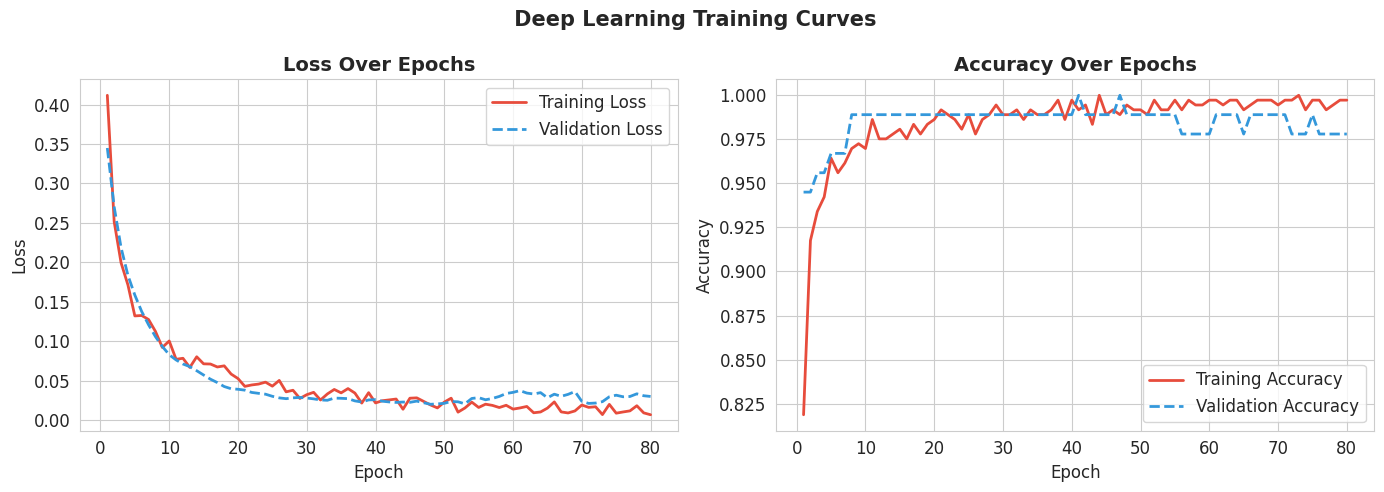

In [ ]:
# ── Plot Training Curves (Loss and Accuracy) ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history.history['loss']) + 1)

# ─ Loss Curve ─
axes[0].plot(epochs_range, history.history['loss'],
 color='#e74c3c', linewidth=2, label='Training Loss')
axes[0].plot(epochs_range, history.history['val_loss'],
 color='#3498db', linewidth=2, linestyle='--', label='Validation Loss')
axes[0].set_title('Loss Over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# ─ Accuracy Curve ─
axes[1].plot(epochs_range, history.history['accuracy'],
 color='#e74c3c', linewidth=2, label='Training Accuracy')
axes[1].plot(epochs_range, history.history['val_accuracy'],
 color='#3498db', linewidth=2, linestyle='--', label='Validation Accuracy')
axes[1].set_title('Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle(' Deep Learning Training Curves', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ── Evaluate DL model on test set ────────────────────────────────
test_loss, test_acc = dl_model.evaluate(X_test_scaled, y_test, verbose=0)
y_dl_prob = dl_model.predict(X_test_scaled, verbose=0).ravel()
y_dl_pred = (y_dl_prob >= 0.5).astype(int)

print(' Deep Learning Model — Test Results')
print('=' * 45)
print(f' Test Loss : {test_loss:.4f}')
print(f' Test Accuracy : {test_acc:.4f}')
print(f' F1 Score : {f1_score(y_test, y_dl_pred):.4f}')
print(f' AUC Score : {roc_auc_score(y_test, y_dl_prob):.4f}')
print()
print(' Classification Report:')
print(classification_report(y_test, y_dl_pred, target_names=['Malignant', 'Benign']))


 Deep Learning Model — Test Results
 Test Loss : 0.1412
 Test Accuracy : 0.9649
 F1 Score : 0.9718
 AUC Score : 0.9917

 Classification Report:
              precision    recall  f1-score   support

   Malignant       0.93      0.98      0.95        42
      Benign       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



---
## Section 9: Overfitting vs Underfitting

This is one of the most critical concepts in all of machine learning!

### What is Overfitting?
> The model **memorizes** the training data but fails on new (unseen) data.
> High training accuracy, **low test accuracy**.

### What is Underfitting?
> The model is **too simple** to capture patterns. It performs poorly on both training and test data.

### The Sweet Spot = **Good Fit**
> Training accuracy ≈ Test accuracy (both are high)

```
 Underfitting Good Fit Overfitting
 ─────────────────────────────────────────────────────────
 Train acc: 75% Train acc: 95% Train acc: 99%
 Test acc: 72% Test acc: 93% Test acc: 75%
 Gap : 3% Gap : 2% Gap : 24% ← Bad!
```


In [ ]:
# ── Demonstrate Overfitting with a Neural Network ─────────────────
# We'll deliberately train an overly complex model WITHOUT regularization

tf.random.set_seed(42)

# OVERFIT model — too complex, no dropout
overfit_model = keras.Sequential([
 layers.Input(shape=(X_train_scaled.shape[1],)),
 layers.Dense(256, activation='relu'),
 layers.Dense(256, activation='relu'),
 layers.Dense(256, activation='relu'),
 layers.Dense(1, activation='sigmoid')
])
overfit_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_overfit = overfit_model.fit(
 X_train_scaled, y_train,
 epochs=100, batch_size=16,
 validation_split=0.2,
 verbose=0
)

# GOOD model — balanced complexity with dropout
good_model = keras.Sequential([
 layers.Input(shape=(X_train_scaled.shape[1],)),
 layers.Dense(64, activation='relu'),
 layers.Dropout(0.3),
 layers.Dense(32, activation='relu'),
 layers.Dropout(0.2),
 layers.Dense(1, activation='sigmoid')
])
good_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_good = good_model.fit(
 X_train_scaled, y_train,
 epochs=100, batch_size=32,
 validation_split=0.2,
 verbose=0
)

print('[OK] Both models trained!')


[OK] Both models trained!


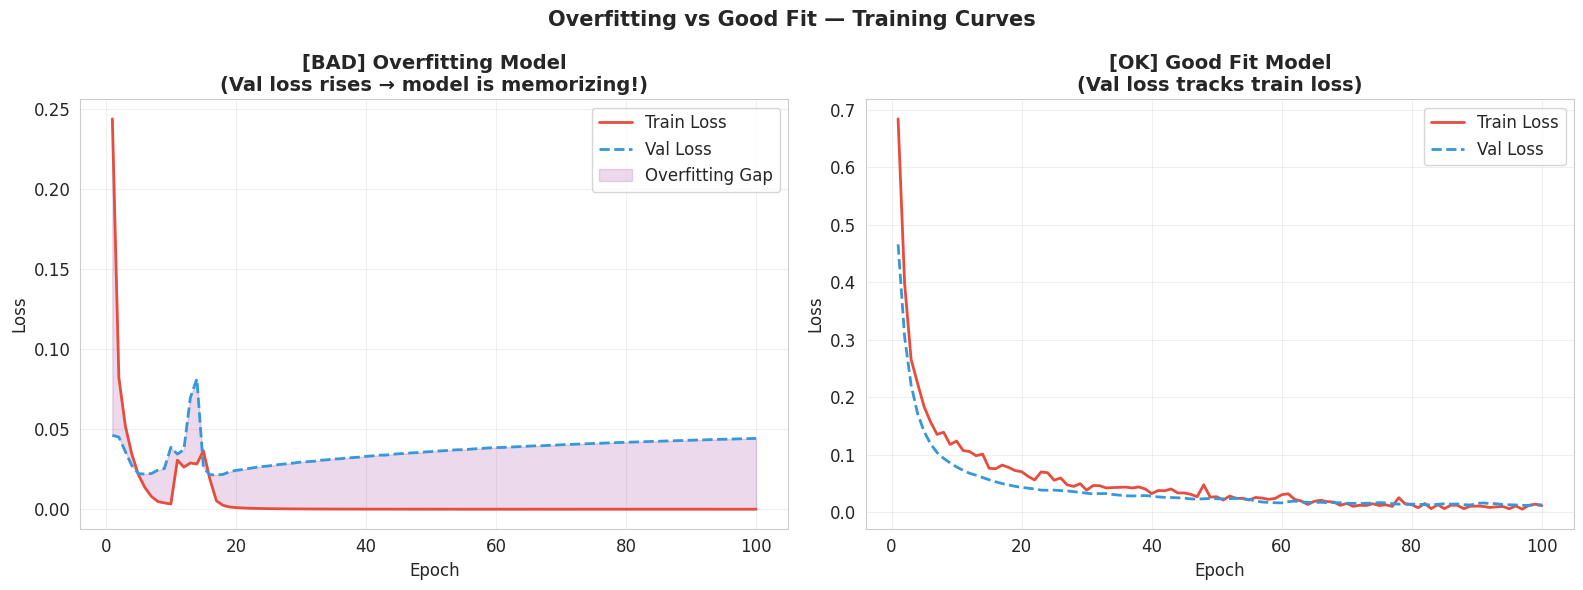


 Overfit vs Good Fit — Final Comparison
 Model                   Train Acc   Test Acc      Gap
 ------------------------------------------------
 Overfit Model              1.0000     0.9649  0.0351 [WARNING]
 Good Model                 0.9918     0.9561  0.0356 [OK]


In [ ]:
# ── Side-by-side comparison: Overfitting vs Good Fit ─────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

epochs_r = range(1, 101)

def plot_curves(ax, hist, title, color_train='#e74c3c', color_val='#3498db'):
 ax.plot(epochs_r, hist['loss'], color=color_train, lw=2, label='Train Loss')
 ax.plot(epochs_r, hist['val_loss'], color=color_val, lw=2, ls='--', label='Val Loss')
 ax.set_title(title, fontsize=14, fontweight='bold')
 ax.set_xlabel('Epoch')
 ax.set_ylabel('Loss')
 ax.legend()
 ax.grid(True, alpha=0.3)

plot_curves(axes[0], history_overfit.history,
 '[BAD] Overfitting Model\n(Val loss rises → model is memorizing!)')
plot_curves(axes[1], history_good.history,
 '[OK] Good Fit Model\n(Val loss tracks train loss)')

# Shade the overfitting gap
axes[0].fill_between(
 epochs_r,
 history_overfit.history['loss'],
 history_overfit.history['val_loss'],
 alpha=0.15, color='purple', label='Overfitting Gap'
)
axes[0].legend()

plt.suptitle('Overfitting vs Good Fit — Training Curves', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Summary comparison ─────────────────────────────────────────────
_, ov_test_acc = overfit_model.evaluate(X_test_scaled, y_test, verbose=0)
_, gd_test_acc = good_model.evaluate(X_test_scaled, y_test, verbose=0)

print('\n Overfit vs Good Fit — Final Comparison')
print('=' * 50)
print(f' {'Model':<22} {'Train Acc':>10} {'Test Acc':>10} {'Gap':>8}')
print(f' {'-'*48}')

ov_tr = history_overfit.history['accuracy'][-1]
gd_tr = history_good.history['accuracy'][-1]

print(f' {'Overfit Model':<22} {ov_tr:>10.4f} {ov_test_acc:>10.4f} {ov_tr-ov_test_acc:>7.4f} [WARNING]')
print(f' {'Good Model':<22} {gd_tr:>10.4f} {gd_test_acc:>10.4f} {gd_tr-gd_test_acc:>7.4f} [OK]')


---
## Section 10: Final Summary & Best Practices

Let's put everything together with a **final model comparison** and a clear reference guide.


 FINAL MODEL LEADERBOARD
                     Accuracy      F1     AUC
Model                                        
Logistic Regression    0.9825  0.9861  0.9954
SVM                    0.9825  0.9861  0.9950
Random Forest          0.9561  0.9655  0.9939
Neural Network (DL)    0.9649  0.9718  0.9917

 Best Model by AUC: Logistic Regression
 Best Model by F1 : Logistic Regression


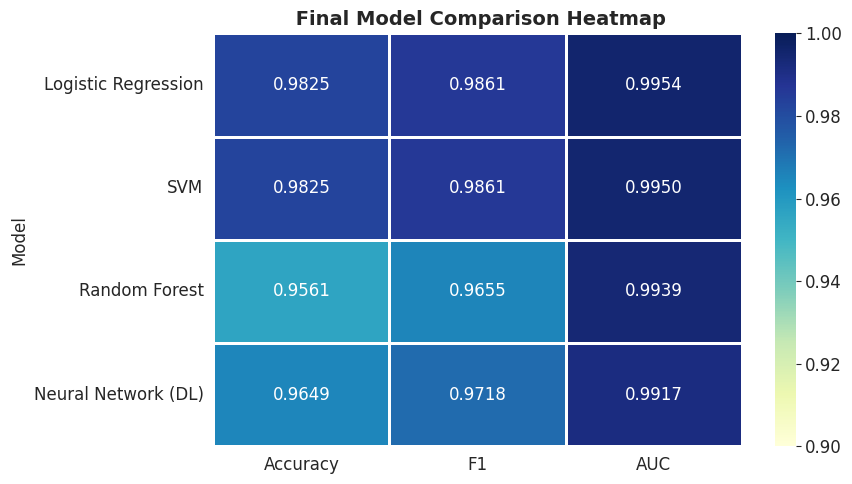

In [ ]:
# ── Final head-to-head comparison: All models ────────────────────
print(' FINAL MODEL LEADERBOARD')
print('=' * 65)

all_results = []

for name, model in trained_models.items():
 y_pred = model.predict(X_test_scaled)
 y_prob = model.predict_proba(X_test_scaled)[:, 1]
 all_results.append({
 'Model' : name,
 'Accuracy' : accuracy_score(y_test, y_pred),
 'F1' : f1_score(y_test, y_pred),
 'AUC' : roc_auc_score(y_test, y_prob),
 'Type' : 'ML'
 })

# Add DL model
all_results.append({
 'Model' : 'Neural Network (DL)',
 'Accuracy' : accuracy_score(y_test, y_dl_pred),
 'F1' : f1_score(y_test, y_dl_pred),
 'AUC' : roc_auc_score(y_test, y_dl_prob),
 'Type' : 'DL'
})

final_df = pd.DataFrame(all_results).set_index('Model').drop('Type', axis=1)
final_df = final_df.round(4).sort_values('AUC', ascending=False)

print(final_df.to_string())
print(f'\n Best Model by AUC: {final_df["AUC"].idxmax()}')
print(f' Best Model by F1 : {final_df["F1"].idxmax()}')

# ── Heatmap of all scores ─────────────────────────────────────────
plt.figure(figsize=(9, 5))
sns.heatmap(final_df, annot=True, fmt='.4f', cmap='YlGnBu',
 linewidths=1, linecolor='white',
 vmin=0.9, vmax=1.0)
plt.title(' Final Model Comparison Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Quick Reference Card

### When to use which metric?

| Situation | Best Metric(s) |
|---|---|
| Balanced classes, general purpose | **Accuracy**, **F1** |
| Imbalanced classes (fraud, disease) | **Precision, Recall, F1, AUC** |
| Missing a positive is catastrophic (cancer, fraud) | **Recall** (minimize False Negatives) |
| False alarms are very costly | **Precision** (minimize False Positives) |
| Comparing models overall | **AUC-ROC** |
| Regression, want intuitive units | **MAE, RMSE** |
| Regression, penalize big errors | **MSE** |
| Regression, overall fit quality | **R²** |
| DL training health check | **Training vs Validation Loss Curve** |

---

### 10 Golden Rules for Model Evaluation

1. [OK] **Always hold out a test set** — never evaluate on training data
2. [OK] **Use cross-validation** for reliable, unbiased estimates
3. [OK] **Pick metrics that match your problem** — accuracy alone is often misleading
4. [OK] **Always look at the confusion matrix** — understand where your model fails
5. [OK] **Check training curves** in deep learning — detect overfitting early
6. [OK] **Scale your features** before training distance-based models (SVM, KNN)
7. [OK] **Use stratified splits** to preserve class balance
8. [OK] **Understand the cost of errors** — FN vs FP may not be equally bad
9. [OK] **Compare against a baseline** — always ask "is this better than random?"
10. [OK] **Report uncertainty** — a mean score without std dev is incomplete

---

**Congratulations! ** You've completed the full Model Evaluation walkthrough.
You now know how to properly evaluate both machine learning and deep learning models like a data scientist.

> **Next Steps:** Try applying these techniques on your own datasets — Kaggle, uci machine learning repository is a great place to start!
